## Astronomía Observacional
## Astropy, Tutorial 2: Reducción de datos espectroscópicos, parte 2: calibración de longitud de onda
María Alejandra Moreno, Cesar Mauricio Mendoza



Este tutorial explicará la extracción del espectro de una lámpara de calibración a partir de una traza existente.

A continuación, se demostrará la identificación de líneas mediante la base de datos de listas de líneas del NIST.

Por último, se mostrará cómo ajustar una solución de longitud de onda a un espectro de calibración, integrando la información de múltiples lámparas de calibración.

In [31]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['image.origin'] = 'lower'  
plt.style.use('dark_background') 

Queremos mostrar imágenes, no matrices, por lo que establecemos el origen en la esquina inferior izquierda.
Configuración opcional: si se ejecuta, se verá bien sobre un fondo oscuro.

In [2]:
from astropy import units as u
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D, Linear1D
from astropy.modeling.fitting import LinearLSQFitter
from IPython.display import Image
# astroquery provides an interface to the NIST atomic line database
from astroquery.nist import Nist

Disponemos de tres espectros de lámparas de calibración: mercurio, criptón y neón. Estos se guardan como archivos .bmp (mapa de bits).

In [11]:
hg_filename = "hg_lamp_1-sixteenth_s.bmp"
kr_filename = "kr_lamp_p6.bmp"
ne_filename = "ne_lamp_1s.bmp"
kr_filenameu = "Kripton.jpeg"
hg_filenameu = "Mercurio.jpeg"
ne_filenameu = "Neon.jpeg"


In [18]:
hg_image = np.array(PILImage.open(hg_filename))
kr_image = np.array(PILImage.open(kr_filename))
ne_image = np.array(PILImage.open(ne_filename))


kr_imageu = np.array(PILImage.open(kr_filenameu).convert("L"))
hg_imageu = np.array(PILImage.open(hg_filenameu).convert("L"))
ne_imageu = np.array(PILImage.open(ne_filenameu).convert("L"))

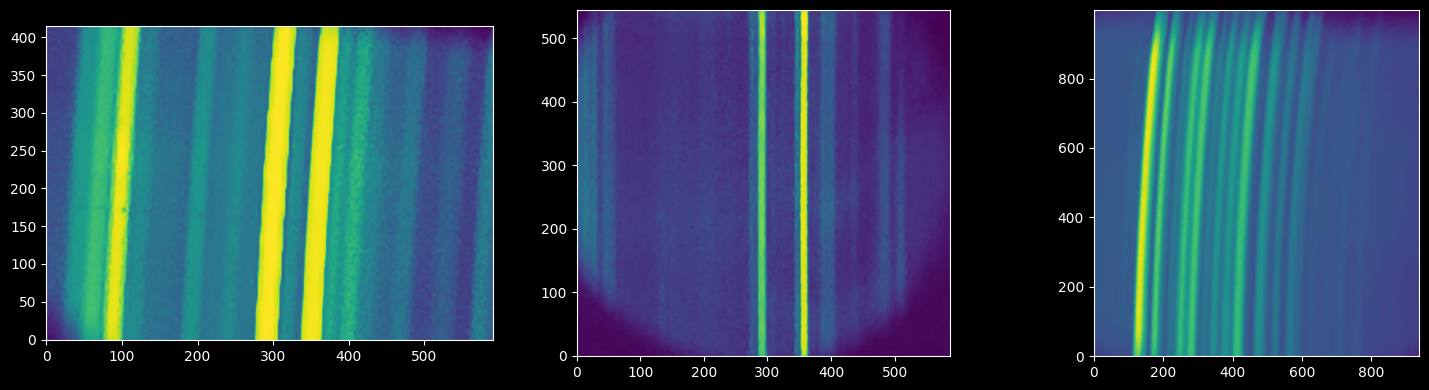

In [20]:
fig, (hg, kr, ne) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.imshow(hg_imageu);
kr.imshow(kr_imageu);
ne.imshow(ne_imageu);
plt.tight_layout()
plt.show()




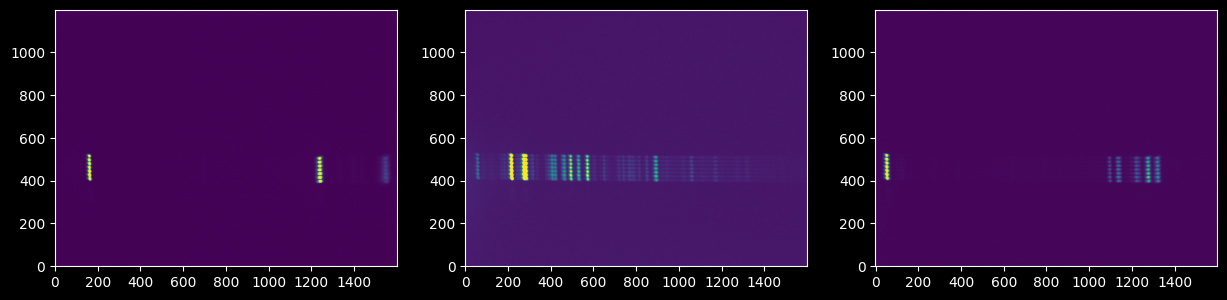

In [21]:
fig, (hgs, nes, krs) = plt.subplots(1, 3, figsize=(15, 4)) 
krs.imshow(kr_image);
nes.imshow(ne_image);
hgs.imshow(hg_image);

Podemos observar al ampliar la imagen que parece haber siete espectros independientes. EN esta caso usamos las lineas experimentales de hg y la tomada del expectro del ejemplo.

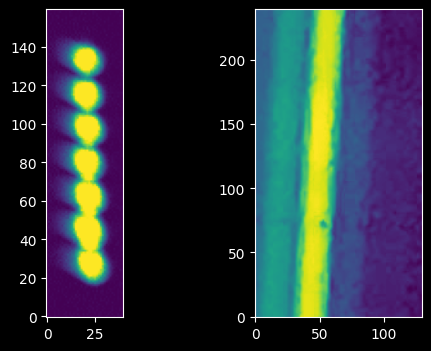

In [38]:

fig, (s, o) = plt.subplots(1,2 , figsize=(6, 4)) 
s.imshow(hg_image[380:540,140:180]);
o.imshow(hg_imageu[100:340 , 50:180])

Recreamos nuestro modelo de traza del Tutorial de Traza Espectroscópica utilizando los modelos ajustados.

(Podríamos haber utilizado la traza empírica directamente, lo que podría resultar en características de ruido ligeramente mejoradas, pero para simplificar y para que ambos cuadernos se puedan utilizar de forma independiente, utilizamos aquí los modelos polinomiales y gaussianos ajustados).

In [39]:
trace_model = Polynomial1D(degree=3, c0=453.6307, c1=-0.01596396, c2=0.0000008259, c3=3.3348554642250357e-09)
trace_profile_model = Gaussian1D(amplitude=123.84846797, mean=0.17719819, stddev=5.10872134)
xaxis = np.arange(hg_image.shape[1])
trace_center = trace_model(xaxis)
npixels_to_cut=15
yaxis = np.arange(-npixels_to_cut, npixels_to_cut)
model_trace_profile = trace_profile_model(yaxis)

Para las firmas que se tomaron en el laboratorio se debe hacer un ajuste polinomicos desde sin asumir las constante creooo...

Luego, utilizamos la traza para extraer los espectros de cada una de las tres lámparas de calibración.

Primero verificamos que las trazas tengan un aspecto aceptable:

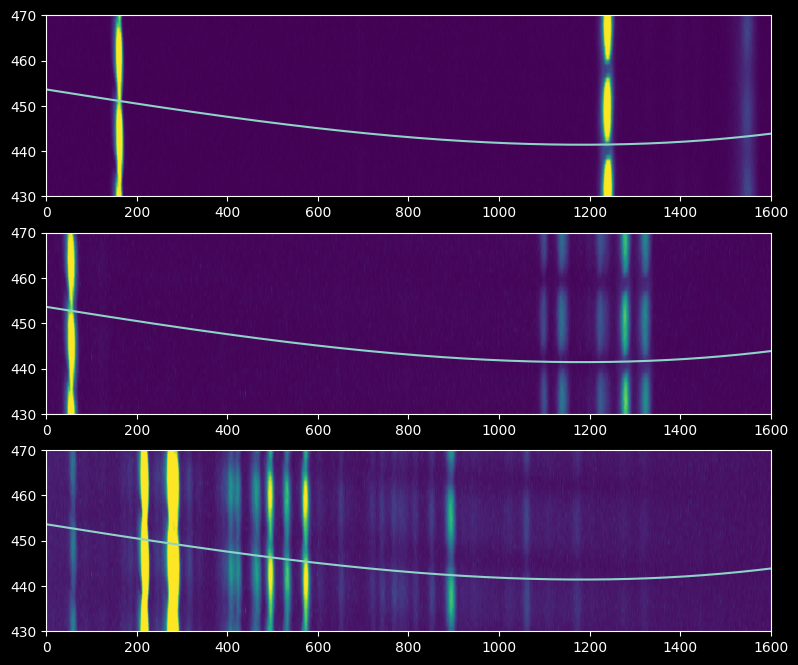

In [40]:
plt.figure(figsize=(16,8))
ax1 = plt.subplot(3,1,1)
ax1.imshow(hg_image[430:470,:], extent=[0,1600,430,470])
ax1.plot(xaxis, trace_center)
ax1.set_aspect(10)
ax2 = plt.subplot(3,1,2)
ax2.imshow(kr_image[430:470,:], extent=[0,1600,430,470])
ax2.plot(xaxis, trace_center)
ax2.set_aspect(10)
ax3 = plt.subplot(3,1,3)
ax3.imshow(ne_image[430:470,:], extent=[0,1600,430,470])
ax3.plot(xaxis, trace_center)
ax3.set_aspect(10)

Curiosamente, la traza parece pasar por un mínimo entre los espectros individuales, lo que podría indicar que el espectrógrafo se movió o se balanceó entre la traza y las observaciones de calibración de longitud de onda. Sin embargo, hay suficiente señal para extraer un espectro de la lámpara de calibración, y la traza es lo suficientemente perpendicular al eje de dispersión como para que podamos confiar en ella.

En las tres celdas siguientes, extraemos el espectro promedio ponderado por perfil de traza de cada una de las tres lámparas de calibración.

``npixels_to_cut`` define una región de recorte alrededor de la traza, similar a la que se muestra en las figuras anteriores. El ``model_trace_profile``, obtenido anteriormente, es el perfil de transmisión que medimos utilizando la traza estelar.

In [41]:
hg_spectrum = np.array([np.average(hg_image[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=model_trace_profile)
                     for yval, ii in zip(trace_center, xaxis)])

In [42]:
ne_spectrum = np.array([np.average(ne_image[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=model_trace_profile)
                     for yval, ii in zip(trace_center, xaxis)])

In [18]:
kr_spectrum = np.array([np.average(kr_image[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=model_trace_profile)
                     for yval, ii in zip(trace_center, xaxis)])

NameError: name 'kr_spectrum' is not defined

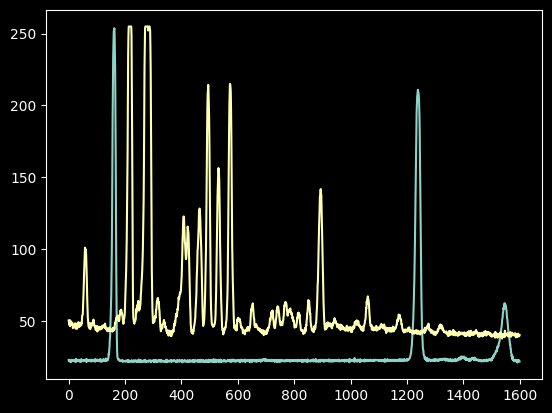

In [43]:
plt.plot(xaxis, hg_spectrum, label='Mercury')
plt.plot(xaxis, ne_spectrum, label='Neon')
plt.plot(xaxis, kr_spectrum, label='Krypton')
plt.legend(loc='best');

Ahora tenemos los espectros de una lámpara de mercurio, una de neón y una de criptón.

Si no tenemos conocimientos previos, tendríamos que hacer conjeturas y comprobaciones. Sin embargo, es útil hacer conjeturas y comprobaciones fundamentadas; Wikipedia es un buen recurso para indicarnos las listas de líneas correctas:

 * https://en.wikipedia.org/wiki/Mercury-vapor_lamp#Emission_line_spectrum
 * https://en.wikipedia.org/wiki/Gas-discharge_lamp#Color

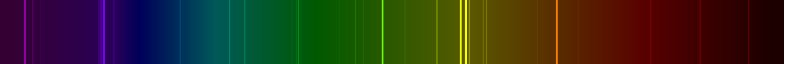

In [20]:
Image("https://upload.wikimedia.org/wikipedia/commons/2/29/Mercury_Spectra.jpg")

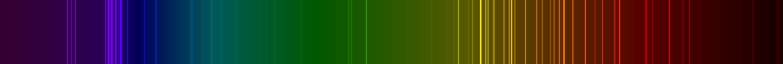

In [21]:
Image("https://upload.wikimedia.org/wikipedia/commons/9/99/Neon_spectra.jpg")

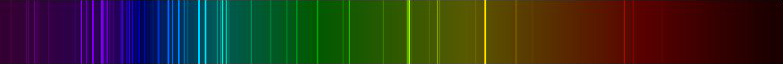

In [22]:
Image("https://upload.wikimedia.org/wikipedia/commons/a/a6/Krypton_Spectrum.jpg")

Comencemos con el mercurio. Usamos un espectro de Wikipedia diferente, un poco más parecido al nuestro, para guiarnos visualmente (tenga en cuenta que las relaciones de las líneas varían de una lámpara a otra, al menos en parte porque cada lámpara contiene gas a una presión diferente).

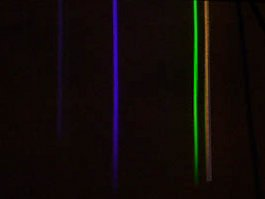

In [23]:
Image("https://upload.wikimedia.org/wikipedia/commons/0/0d/HG-Spektrum_crop.jpg")

Las líneas ópticas de Mercurio, según Wikipedia, se expresan en ángstroms:

* 4047 violeta
* 4358 azul
* 5461 verde
* 5782 amarillo anaranjado
* 6500 rojo

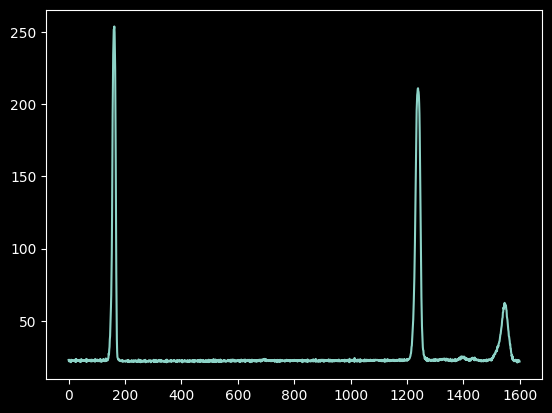

In [24]:
plt.plot(xaxis, hg_spectrum);

En el siguiente paso, debemos anotar qué valores de píxel (aproximados) corresponden a longitudes de onda conocidas.

Adivinar estos valores simplemente observando los espectros y comparándolos con atlas espectrales es difícil y requiere experiencia.

Si tienes espectros tomados con la misma configuración de una fuente conocida, como una estrella A0, podrías usarlos para obtener una "previa" sobre dónde se centra el espectro.
En este caso, nuestro conjunto de espectros incluye Deneb, que es una estrella A. Tiene una línea de absorción clara (que veremos más adelante, en el tutorial 3) alrededor del píxel 750.
Las estrellas A tienen líneas de absorción de hidrógeno profundas en su atmósfera y poco más, por lo que probablemente se trate de una línea de hidrógeno.
Podemos asumir que es H-alfa o H-beta, ya que ambas están en el campo óptico y son intensas (las líneas superiores, como H-delta, están muy juntas, por lo que si fuera una de ellas, esperaríamos ver varias líneas adyacentes).

Por lo tanto, podemos comparar nuestro espectro con los atlas, suponiendo que el píxel 750 es H-beta o H-alfa. Usando la lista de líneas, podemos ver que el rojo es bastante improbable: H-alfa está en 6563, por lo que habría una línea justo al lado. Si es H-beta, hay líneas a ambos lados y hay un doblete a la derecha.

El siguiente truco es averiguar en qué dirección aumenta la longitud de onda: ¿hacia la izquierda o hacia la derecha? Mercurio no ayuda con eso, ya que los dobletes azul-violeta y verde-amarillo están aproximadamente a la misma distancia entre sí. Resulta, a partir de un trabajo de conjeturas y comprobaciones, que la longitud de onda aumenta hacia la izquierda.

De nuevo, esta parte es difícil de hacer directamente a partir de los datos; generalmente, se espera tener una idea bastante precisa de la longitud de onda que se está observando antes de observar.

In [25]:
guessed_wavelengths = [546.1, 435.8, 404.7]
guessed_xvals = [165, 1230, 1550]

## Mejorando nuestras suposiciones

Podemos determinar mucho mejor los valores X de los píxeles tomando la coordenada ponderada por la intensidad (momento 1):

In [26]:
npixels = 15
improved_xval_guesses = [np.average(xaxis[g-npixels:g+npixels],
                                    weights=hg_spectrum[g-npixels:g+npixels] - np.median(hg_spectrum))
                         for g in guessed_xvals]
improved_xval_guesses

[160.736647147187, 1235.1743737214103, 1548.2834755459144]

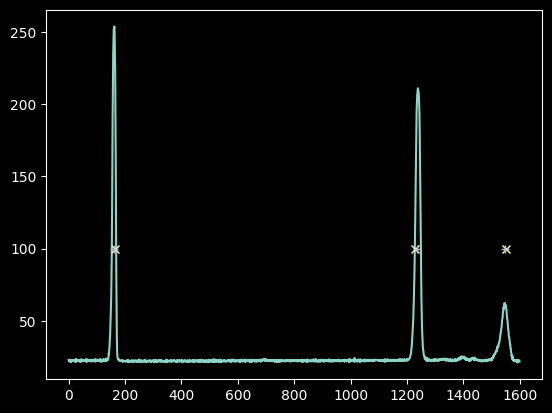

In [27]:
plt.plot(xaxis, hg_spectrum)
plt.plot(guessed_xvals, [100]*3, 'x')
plt.plot(improved_xval_guesses, [100]*3, '+');

Solo tenemos tres puntos de datos, pero eso es suficiente para ajustar un modelo lineal y aún tenemos un punto libre para verificar que lo hicimos cerca de lo correcto:

In [28]:
linfitter = LinearLSQFitter()

Usamos un modelo `Linear1D` porque querremos usar su inverso más adelante (otros modelos no son invertibles)

In [29]:
wlmodel = Linear1D()
linfit_wlmodel = linfitter(model=wlmodel, x=improved_xval_guesses, y=guessed_wavelengths)
wavelengths = linfit_wlmodel(xaxis) * u.nm
linfit_wlmodel

<Linear1D(slope=-0.10210002, intercept=562.40076754)>

Tenga en cuenta esta pendiente ajustada: cada píxel mide aproximadamente 0,1 nm (aproximadamente 1 angstrom) y la longitud de onda aumenta hacia la izquierda.

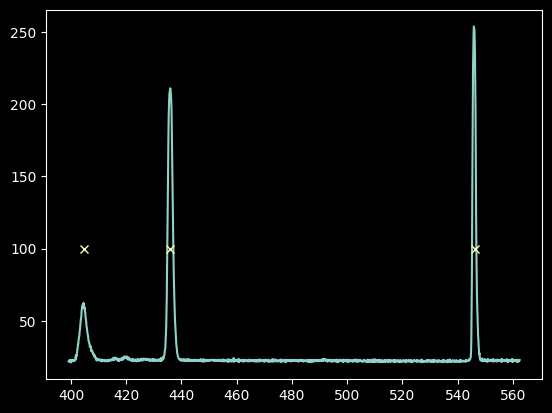

In [30]:
plt.plot(wavelengths, hg_spectrum)
plt.plot(guessed_wavelengths, [100]*3, 'x');

Mostramos nuestro modelo $\lambda(x)$ frente a las "conjeturas" de entrada:

Text(0.5, 0, 'x (pixels)')

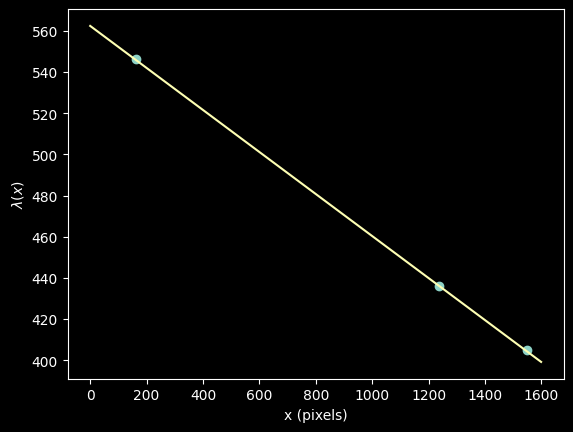

In [31]:
plt.plot(improved_xval_guesses, guessed_wavelengths, 'o')
plt.plot(xaxis, wavelengths, '-')
plt.ylabel("$\lambda(x)$")
plt.xlabel("x (pixels)")

¡De hecho, un modelo lineal encaja perfectamente!

Podemos consultar las listas de líneas de neón y kriptón para ver qué tan bien lo hicimos y quizás intentar mejorar nuestro ajuste.

El NIST, el Instituto Nacional de Estándares y Tecnología, mantiene [listas de líneas atómicas](https://physics.nist.gov/PhysRefData/ASD/lines_form.html). Sin embargo, no tenemos una forma directa de saber qué transiciones de estos átomos usar. Sin embargo, existen algunas heurísticas que podemos aplicar.

In [32]:
# we adopt the minimum/maximum wavelength from our linear fit
minwave = wavelengths.min()
maxwave = wavelengths.max()
# then we search for atomic lines
# We are only interested in neutral lines, assuming the lamps are not hot enough to ionize the atoms
mercury_lines = Nist.query(minwav=minwave,
                           maxwav=maxwave,
                           linename='Hg I')
krypton_lines = Nist.query(minwav=minwave,
                           maxwav=maxwave,
                           linename='Kr I')
neon_lines = Nist.query(minwav=minwave,
                        maxwav=maxwave,
                        linename='Ne I')

Primero, podemos observar lo que informa el NIST para el espectro de mercurio que ya ajustamos:

(Tenga en cuenta que las longitudes de onda corresponden al *aire*, no al vacío).

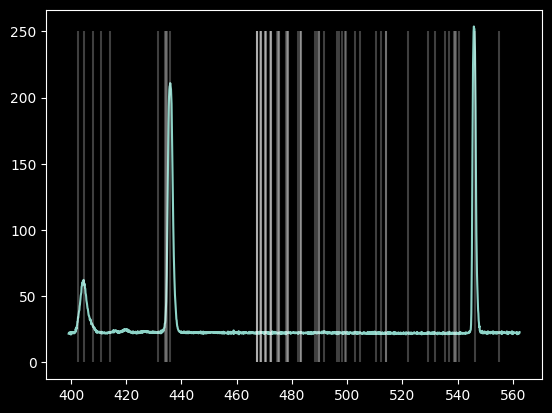

In [33]:
plt.plot(wavelengths, hg_spectrum)
plt.vlines(mercury_lines['Observed'], 0, 250, 'w', alpha=0.25);

La base de datos contiene *muchas* más líneas de las que vimos.

La "Intensidad Relativa" (Rel. Int) proporciona una descripción cualitativa del espectro de emisión de un elemento específico en una fuente específica (de baja densidad).

Podemos seleccionar esa columna si la depuramos un poco (hay algunas entradas en blanco).

In [34]:
# these lines downselect from the table to keep only those that have usable "Relative Intensity" measurements
# first, we get rid of those whose 'Rel.' column is masked out or is an asterisk
hg_keep = (~mercury_lines['Rel.'].mask) & (mercury_lines['Rel.'] != "*")
hg_wl_tbl = mercury_lines['Observed'][hg_keep]
# then, we collect the 'Rel.' values and convert them from strings to floats
hg_rel_tbl = np.array([float(x) for x in mercury_lines['Rel.'][hg_keep]])

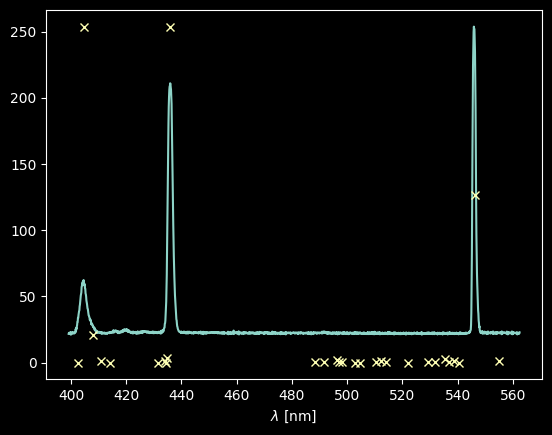

In [35]:
plt.plot(wavelengths, hg_spectrum)
# we normalize the relative intensities to match the intensity of the spectrum so we can see both on the same plot
# since they're just relative intensities, their amplitudes are arbitrary anyway
plt.plot(hg_wl_tbl, hg_rel_tbl / hg_rel_tbl.max() * hg_spectrum.max(), 'x')
plt.xlabel("$\lambda$ [nm]");

¡Bien! Fíjate que solo se ven las tres líneas más brillantes, y quizás una tercera alrededor de los 408 nm.

Intentemos lo mismo con las demás líneas (ten en cuenta que la técnica cambia; esto se debe a que las tablas del NIST no están formateadas para ser legibles por máquina).

In [36]:
ne_keep = np.array(['*' not in x for x in neon_lines['Rel.']])
ne_wl_tbl = neon_lines['Observed'][ne_keep]
ne_rel_tbl = np.array([float(x) for x in neon_lines['Rel.'][ne_keep]])

In [37]:
kr_keep = np.array([('*' not in x) and ('h' not in x) and ('-' not in x) for x in krypton_lines['Rel.']])
kr_wl_tbl = krypton_lines['Observed'][kr_keep]
kr_rel_tbl = np.array([float(x) for x in krypton_lines['Rel.'][kr_keep]])

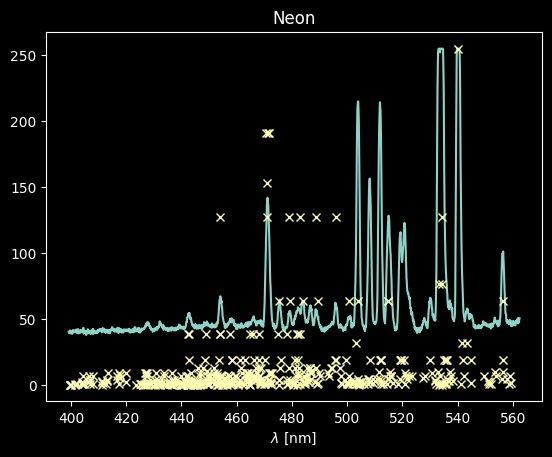

In [38]:
plt.plot(wavelengths, ne_spectrum)
plt.plot(ne_wl_tbl, ne_rel_tbl / ne_rel_tbl.max() * ne_spectrum.max(), 'x')
plt.xlabel("$\lambda$ [nm]")
plt.title("Neon");

En el caso de Neon, hay muchas líneas que coinciden, pero muchas que no coinciden bien (detectamos muchas que tienen valores "Rel" bajos)

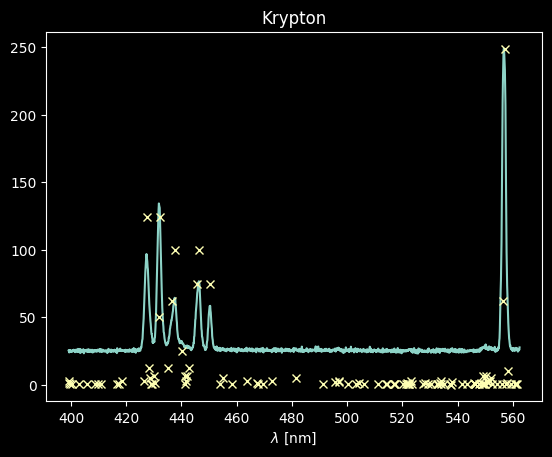

In [39]:
plt.plot(wavelengths, kr_spectrum)
plt.plot(kr_wl_tbl, kr_rel_tbl / kr_rel_tbl.max() * kr_spectrum.max(), 'x')
plt.xlabel("$\lambda$ [nm]")
plt.title("Krypton");

El espectro de criptón será mucho más fácil de manejar: simplemente seleccionamos aquellas líneas con intensidades > 70 en la escala anterior:

In [40]:
kr_rel_intens =  kr_rel_tbl / kr_rel_tbl.max() * kr_spectrum.max()
kr_keep_final = kr_rel_intens > 70
kr_wl_final = kr_wl_tbl[kr_keep_final]

Luego tomamos estas longitudes de onda de criptón y las convertimos nuevamente al espacio de píxeles:

In [41]:
# the linear model has an inverse function that takes y = m x + b and converts to x = (y - b) / m
kr_pixel_vals = linfit_wlmodel.inverse(kr_wl_final)

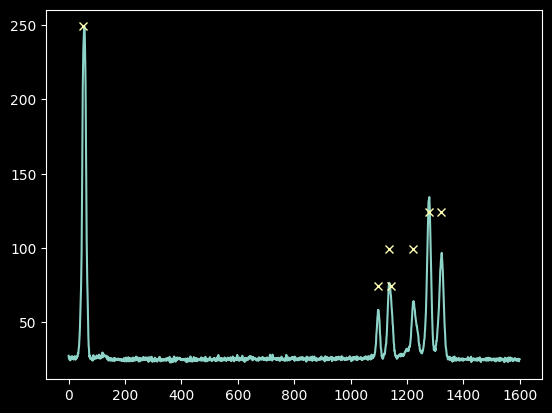

In [42]:
plt.plot(xaxis, kr_spectrum)
plt.plot(kr_pixel_vals, kr_rel_intens[kr_keep_final], 'x');

Al igual que con el mercurio mencionado anteriormente, seleccionamos una subregión y medimos la posición del pico ponderado por intensidad en número de píxeles para medir con precisión el centro del píxel.

¡Pero aquí debemos tener cuidado! ¡Estos picos están muy cerca! ¿Podemos seguir usando un rango de píxeles de +/-15?

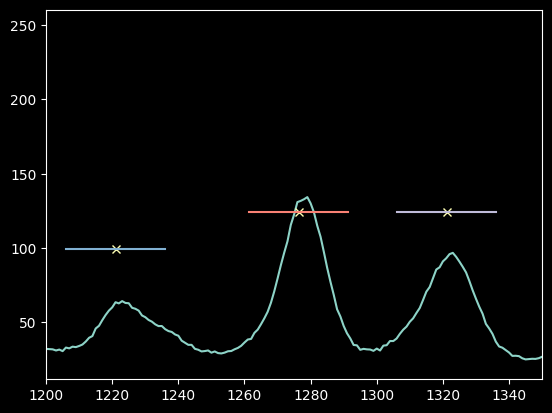

In [43]:
# Examine the pixel range, +/-15 pix, to see if it results in line overlaps
plt.plot(xaxis, kr_spectrum)
plt.plot(kr_pixel_vals, kr_rel_intens[kr_keep_final], 'x')
for xx, yy in zip(kr_pixel_vals, kr_rel_intens[kr_keep_final]):
    plt.plot([xx-15,xx+15], [yy,yy], ) # plot horizontal lines at each peak location
plt.xlim(1200,1350);

Sí, 15 píxeles todavía se ven bien.

Si estas líneas se hubieran superpuesto, habríamos querido reducir el rango de píxeles.

In [44]:
# note that we have to force the pixel-center guesses to be integers for slicing:
npixels = 15
improved_xval_guesses_kr = [np.average(xaxis[g-npixels:g+npixels],
                                    weights=kr_spectrum[g-npixels:g+npixels] - np.median(kr_spectrum))
                         for g in map(int, kr_pixel_vals)]
improved_xval_guesses_kr

[1321.3688120277354,
 1277.1972221744618,
 1222.9735220981242,
 1140.2780334574877,
 1137.7518421055224,
 1097.715582422276,
 54.2769391627054]

Ahora podemos graficar estos números de píxeles de mejor ajuste contra las longitudes de onda "reales" y superponer nuestro modelo de mejor ajuste anterior de mercurio:

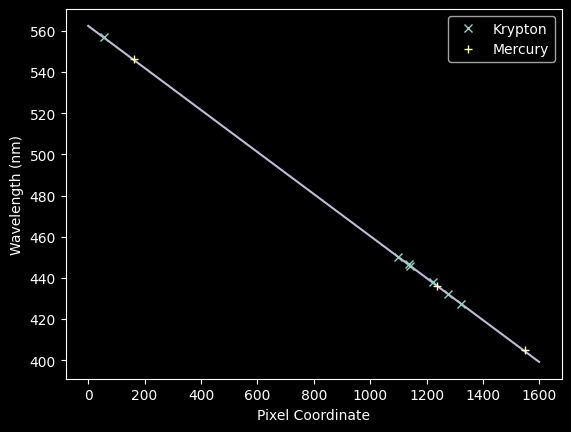

In [45]:
plt.plot(improved_xval_guesses_kr, kr_wl_final, 'x', label='Krypton')
plt.plot(improved_xval_guesses, guessed_wavelengths, '+', label='Mercury')
plt.plot(xaxis, wavelengths, zorder=-5)
plt.legend(loc='best')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength (nm)");

Ahora podemos ajustar conjuntamente los espectros de Kr + Hg con un nuevo modelo:

In [46]:
# we concatenate the data sets together
xvals_hg_plus_kr = np.concatenate([improved_xval_guesses,
                                   improved_xval_guesses_kr])
waves_hg_plus_kr = np.concatenate([guessed_wavelengths, kr_wl_final])
linfit_wlmodel_hgkr = linfitter(model=wlmodel,
                                x=xvals_hg_plus_kr,
                                y=waves_hg_plus_kr)
linfit_wlmodel_hgkr

<Linear1D(slope=-0.10221918, intercept=562.56900643)>

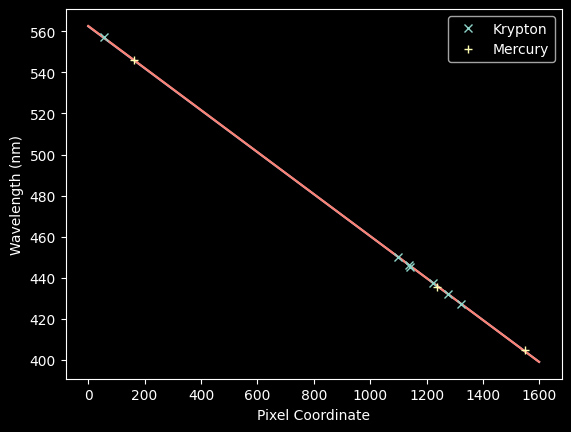

In [47]:
# re-plot the data with the fit overlaid
plt.plot(improved_xval_guesses_kr, kr_wl_final, 'x', label='Krypton')
plt.plot(improved_xval_guesses, guessed_wavelengths, '+', label='Mercury')
plt.plot(xaxis, wavelengths, zorder=-5)
plt.plot(xaxis, linfit_wlmodel_hgkr(xaxis), zorder=-5)
plt.legend(loc='best')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength (nm)");

Son casi indistinguibles, pero veamos los residuos de cada uno:

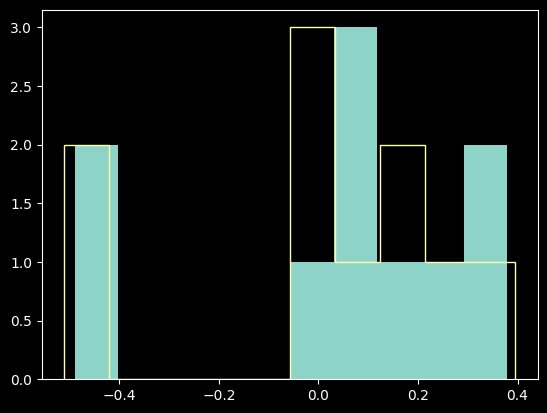

In [48]:
residuals_hgonlymodel = np.array(waves_hg_plus_kr) - linfit_wlmodel(xvals_hg_plus_kr)
residuals_hgkrmodel = np.array(waves_hg_plus_kr) - linfit_wlmodel_hgkr(xvals_hg_plus_kr)
plt.hist(residuals_hgonlymodel, label='Hg-only fit', histtype='stepfilled')
plt.hist(residuals_hgkrmodel, label='Hg-only fit', histtype='step');

Las diferencias son bastante marginales; el ajuste solo con Hg fue realmente bueno.

¿Tienen alguna forma los residuos?

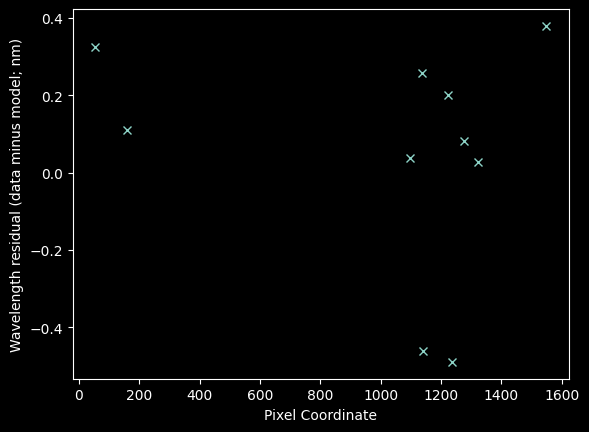

In [49]:
plt.plot(xvals_hg_plus_kr, residuals_hgonlymodel, 'x')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength residual (data minus model; nm)");

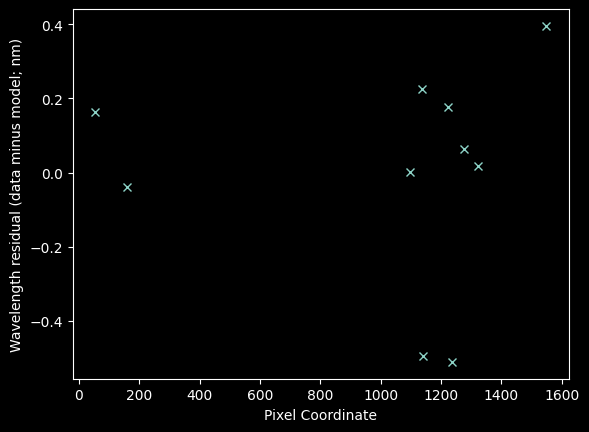

In [50]:
plt.plot(xvals_hg_plus_kr, residuals_hgkrmodel, 'x')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength residual (data minus model; nm)");

En resumen, no, no hay indicios de estructura. Si la hubiera, quizá convendría ajustar un modelo de orden superior.

También podemos estimar una estadística similar a chi-cuadrado (aunque tenga en cuenta que este *no* es el valor $\chi^2$ que usaríamos para evaluar la bondad del ajuste porque *no* hemos estimado la incertidumbre en cada punto de longitud de onda).

In [51]:
resid2_hgonly = (residuals_hgonlymodel**2).sum()
resid2_hgkr = (residuals_hgkrmodel**2).sum()
resid2_hgonly, resid2_hgkr

(0.8290377437520604, 0.7755414146718849)

Estas diferencias también son muy pequeñas, lo que nuevamente sugiere que el ajuste solo de Hg fue realmente bueno.

¿Por qué nos molestamos en realizar todas estas comprobaciones si el ajuste solo de Hg fue perfecto?

Además de simplemente desconocerlo, es común que los espectrógrafos presenten una dispersión ligeramente no lineal al medirse en un amplio rango de longitudes de onda, por lo que queremos asegurarnos de no haber pasado por alto ninguna de estas curvaturas.

También queremos medir la incertidumbre en nuestra calibración de longitud de onda.

Ahora volvamos y midamos el espectro de neón.

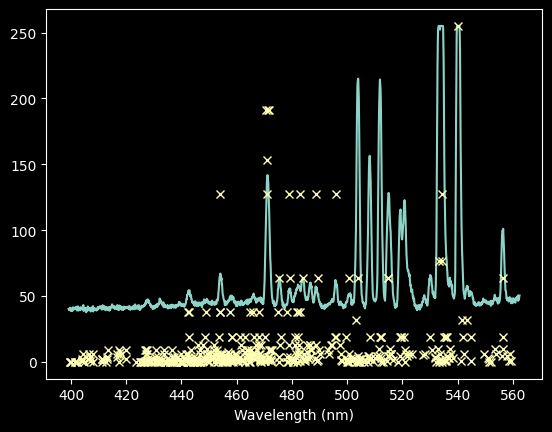

In [52]:
ne_rel_intens = ne_rel_tbl / ne_rel_tbl.max() * ne_spectrum.max()
plt.plot(wavelengths, ne_spectrum)
plt.plot(ne_wl_tbl, ne_rel_intens, 'x')
plt.xlabel('Wavelength (nm)');

Podemos intentar mantener sólo aquellos con intensidad >100, aunque perderemos algunas líneas.

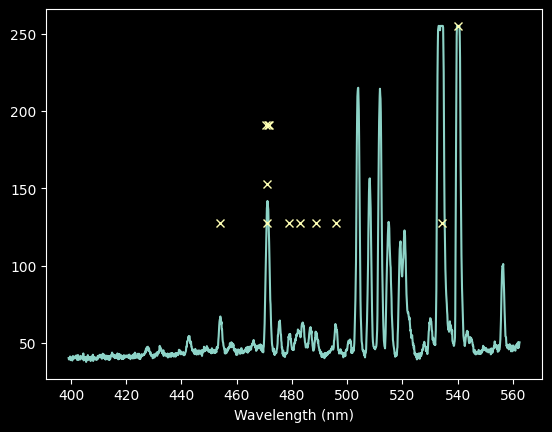

In [53]:
ne_keep_final = ne_rel_intens > 100
plt.plot(wavelengths, ne_spectrum)
plt.plot(ne_wl_tbl[ne_keep_final], ne_rel_intens[ne_keep_final], 'x')
plt.xlabel('Wavelength (nm)');

In [54]:
# select down to just those lines we want to keep
ne_wl_final = ne_wl_tbl[ne_keep_final]
ne_pixel_vals = linfit_wlmodel.inverse(ne_wl_final)

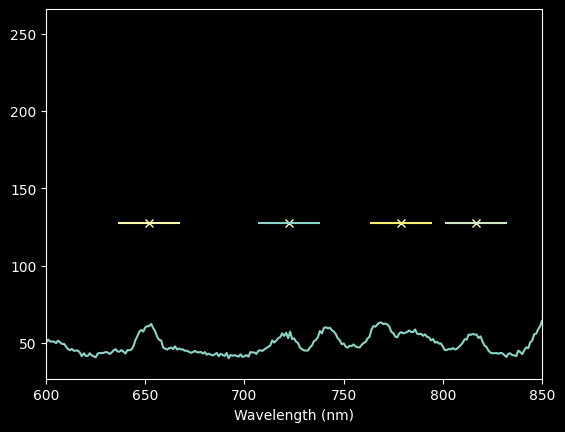

In [55]:
# check for overlaps again (in the densest part of the spectrum)
plt.plot(xaxis, ne_spectrum)
plt.plot(ne_pixel_vals, ne_rel_intens[ne_keep_final], 'x')
for xx, yy in zip(ne_pixel_vals, ne_rel_intens[ne_keep_final]):
    plt.plot([xx-15,xx+15], [yy,yy], )
plt.xlim(600,850)
plt.xlabel('Wavelength (nm)');

Para Neón, nuestro enfoque automatizado no es muy bueno (el tercer punto desde la izquierda no está en un pico), y preferimos usar un rango de píxeles más estrecho.

Aun así, en lugar de retroceder e identificar laboriosamente cada línea, nos quedaremos con un enfoque semiautomatizado, usando simplemente un rango más estrecho alrededor de cada pico.

In [56]:
npixels = 10
improved_xval_guesses_ne = [np.average(xaxis[g-npixels:g+npixels],
                                    weights=ne_spectrum[g-npixels:g+npixels] - np.median(ne_spectrum))
                         for g in map(int, ne_pixel_vals)]
improved_xval_guesses_ne

[1060.5183193475166,
 895.2424884504669,
 893.670848263007,
 892.9232835842486,
 892.082009702997,
 890.6754750779604,
 814.5085554585149,
 776.6287593955387,
 720.1158679501369,
 651.4261979644568,
 275.48231610553455,
 216.88320524067413]

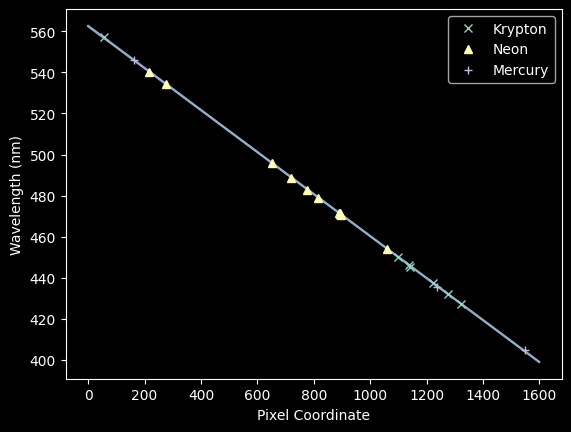

In [57]:
plt.plot(improved_xval_guesses_kr, kr_wl_final, 'x', label='Krypton')
plt.plot(improved_xval_guesses_ne, ne_wl_final, '^', label='Neon')
plt.plot(improved_xval_guesses, guessed_wavelengths, '+', label='Mercury')
plt.plot(xaxis, wavelengths, zorder=-5)
plt.plot(xaxis, linfit_wlmodel_hgkr(xaxis), zorder=-5)
plt.legend(loc='best')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength (nm)");

Concatenamos las líneas de Neón en el espectro y volvemos a ajustarlas.

In [58]:
xvals_hg_plus_kr_plus_ne = list(improved_xval_guesses) + list(improved_xval_guesses_kr) + list(improved_xval_guesses_ne)
waves_hg_plus_kr_plus_ne = list(guessed_wavelengths) + list(kr_wl_final) + list(ne_wl_final)
linfit_wlmodel_hgkrne = linfitter(model=wlmodel, x=xvals_hg_plus_kr_plus_ne, y=waves_hg_plus_kr_plus_ne)
linfit_wlmodel_hgkrne

<Linear1D(slope=-0.10213663, intercept=562.38704033)>

In [59]:
residuals_hgmodel_nedata = np.array(waves_hg_plus_kr_plus_ne) - linfit_wlmodel(xvals_hg_plus_kr_plus_ne)
residuals_hgkrmodel_nedata = np.array(waves_hg_plus_kr_plus_ne) - linfit_wlmodel_hgkr(xvals_hg_plus_kr_plus_ne)
residuals_hgkrnemodel_nedata = np.array(waves_hg_plus_kr_plus_ne) - linfit_wlmodel_hgkrne(xvals_hg_plus_kr_plus_ne)

In [60]:
# calculate and compare the squared residuals
# the model calculated for Hg-only works better than that for Krypton, but the optimal linear model is calculated
# from all data, with a squared residual of 1.26 nm
resid2_hgonly = (residuals_hgmodel_nedata**2).sum()
resid2_hgkr = (residuals_hgkrmodel_nedata**2).sum()
resid2_hgkrne = (residuals_hgkrnemodel_nedata**2).sum()
resid2_hgonly, resid2_hgkr, resid2_hgkrne

(1.2974074905658441, 1.5361847762868206, 1.2470762011963399)

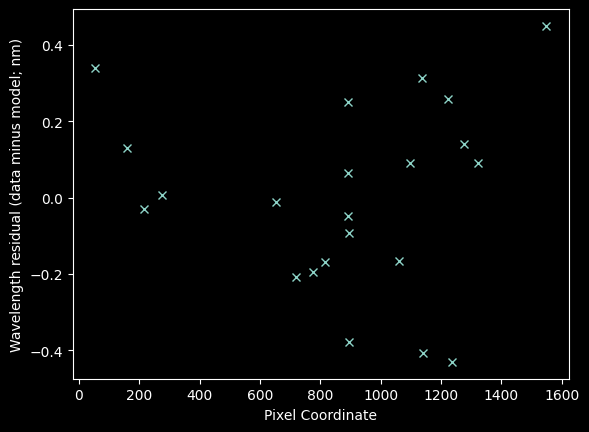

In [61]:
plt.plot(xvals_hg_plus_kr_plus_ne, residuals_hgkrnemodel_nedata, 'x')
plt.xlabel("Pixel Coordinate")
plt.ylabel("Wavelength residual (data minus model; nm)");

Finalmente, con el neón incluido, hay un indicio de cierta estructura.

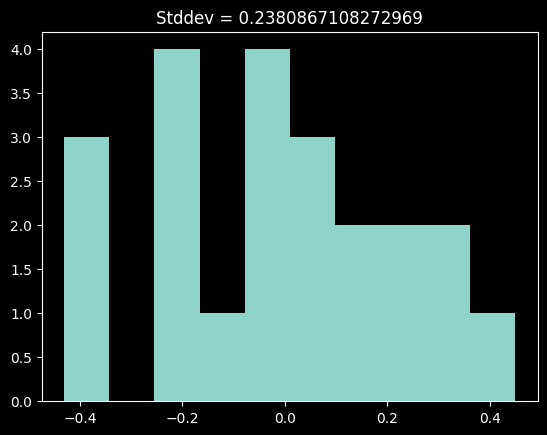

In [62]:
plt.hist(residuals_hgkrnemodel_nedata)
plt.title(f"Stddev = {residuals_hgkrnemodel_nedata.std()}");

Este histograma quizás esté un poco sesgado.

Puede haber cierta curvatura en este espectro, pero la evidencia no es muy convincente, en particular dada la naturaleza incierta de los ajustes de la línea Neon.

La dispersión de estos residuos es de aproximadamente 0,24 nm. Analizaremos este valor con más detalle más adelante.

## Medición de la incertidumbre de la solución de longitud de onda

Para evaluar nuestra incertidumbre, primero analicemos la incertidumbre en el valor del píxel inferido al observar una sola línea en el espectro de mercurio.

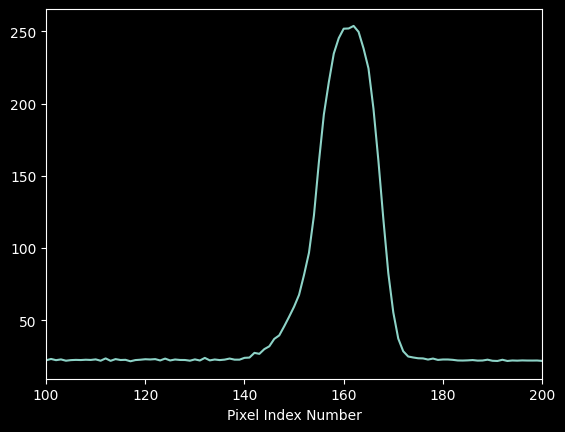

In [63]:
plt.plot(xaxis, hg_spectrum)
plt.xlim(100,200)
plt.xlabel("Pixel Index Number");

Podemos obtener una estimación empírica *aproximada* de la incertidumbre por píxel tomando la desviación estándar de una parte "en blanco" del espectro:

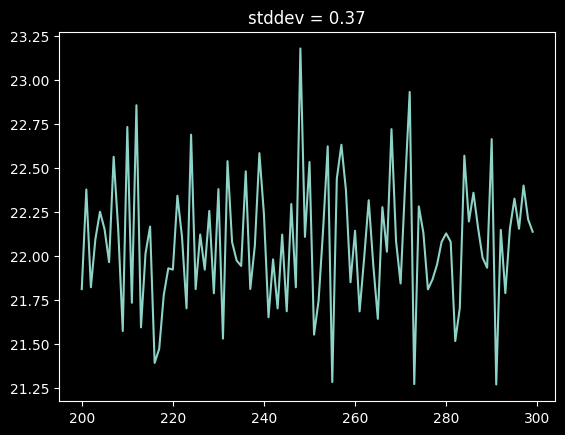

In [64]:
plt.plot(xaxis[200:300], hg_spectrum[200:300])
noise_estimate = hg_spectrum[200:300].std()
plt.title(f"stddev = {noise_estimate:0.2f}");

The moment-1 estimate of the peak location is, for a spectrum $f(x)$ and pixel location $x$ 
$$ m_1 = \frac{\Sigma x f(x)}{\Sigma f(x)} $$

which, through propagation of error, gives us variance of moment 1:

$$\sigma_{m_1}^2 =  \left(\frac{\Sigma \left[ (x-m_1)^2   \sigma_{f(x)}^2 \right]}{\left(\Sigma f(x)\right)^2}  +
   \frac{\sigma_{\Sigma f(x)}^2 \Sigma \left[ (x-m_1)^2 f(x)^2 \right]}{\left(\Sigma f(x)\right)^4} \right)$$
   
   where 
$   \sigma_{\Sigma f(x)}^2 = \Sigma \sigma_{f(x)}^2 = N \sigma_{f(x)}^2 $

In [65]:
cutout = hg_spectrum[100:200] - np.median(hg_spectrum)
xcutout = xaxis[100:200]
m1 = (xcutout * cutout).sum() / cutout.sum()
m1

160.14071738720793

In [66]:
# Uncertainty on moment 1
sigma_m1_left = ((xcutout-m1)**2 * noise_estimate**2).sum() / cutout.sum()**2
sigma_m1_right = (xcutout.size * noise_estimate**2) * ((xcutout-m1)**2*cutout**2).sum() / cutout.sum()**4
sigma_m1 = sigma_m1_left + sigma_m1_right
sigma_m1

0.0012527166750909403

In [67]:
print(f"Moment analysis yields m1 = {m1:0.3f} +/- {sigma_m1:0.3f} pixels")

Moment analysis yields m1 = 160.141 +/- 0.001 pixels


La incertidumbre es de aproximadamente una milésima de píxel para una línea brillante. Puede ser algo mayor para líneas más tenues, pero sigue siendo mucho menor que la dispersión observada.

Podemos demostrar que la incertidumbre por línea es insignificante observando una tenue línea de neón:

In [ ]:
# cut out a line and compute its moment 1
cutoutne = ne_spectrum[640:660] - np.median(ne_spectrum)
xcutoutne = xaxis[640:660]
m1ne = (xcutoutne * cutoutne).sum() / cutoutne.sum()

In [ ]:
# estimate the per-pixel error in the Neon spectrum
ne_noise_estimate = ne_spectrum[1400:1600].std()
ne_noise_estimate

1.0704108932039562

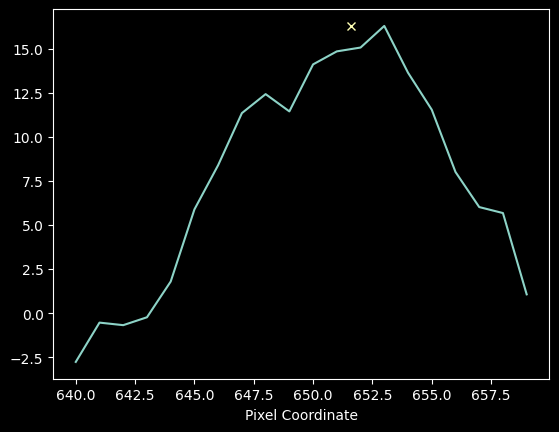

In [ ]:
plt.plot(xcutoutne, cutoutne)
plt.plot(m1ne, cutoutne.max(), 'x')
plt.xlabel("Pixel Coordinate");

In [ ]:
# calculate Neon line centroid uncertainty
sigma_m1_left = ((xcutoutne-m1ne)**2 * ne_noise_estimate**2).sum() / cutoutne.sum()**2
sigma_m1_right = (xcutoutne.size * ne_noise_estimate**2) * ((xcutoutne-m1ne)**2*cutoutne**2).sum() / cutoutne.sum()**4
sigma_m1_ne = sigma_m1_left + sigma_m1_right
sigma_m1_ne

0.03746963744056958

In [ ]:
print(f"Moment analysis for the faint Neon line yields m1 = {m1ne:0.4f} +/- {sigma_m1_ne:0.4f} pixels")

Moment analysis for the faint Neon line yields m1 = 651.6098 +/- 0.0375 pixels


Este error es aproximadamente 40 veces mayor, pero aún mucho menor que el ancho de un píxel.

Nuestro mejor ajuste indica que cada píxel mide aproximadamente 0,1 nm (esto se obtiene de la pendiente de la línea ajustada), por lo que nuestra incertidumbre es de 0,0001 nm a 0,004 nm. La dispersión en los residuos es de 0,23 nm, por lo que no se explica por la incertidumbre estadística de nuestro ajuste formal.

In [ ]:
print(f"Standard Deviation of the residuals = {residuals_hgkrnemodel_nedata.std()} nm, "
      f"Faint Line uncertainty = {sigma_m1_ne * linfit_wlmodel_hgkrne.slope} nm")

Standard Deviation of the residuals = 0.2380867108272969 nm, Faint Line uncertainty = -0.003827022595145174 nm


## ¿Qué representa el residuo?

El residuo de nuestro ajuste nos da una idea de la incertidumbre *sistemática* derivada de la combinación de líneas y ajustes imperfectos. Sabemos, gracias a las listas de líneas del NIST, que en algunos casos hay varias líneas que no pudimos distinguir fácilmente en el espectro; esto añade un ligero sesgo a las ubicaciones de los píxeles inferidas.

También puede haber efectos sutiles del propio espectrógrafo que causen pequeñas variaciones sistemáticas en la solución de longitud de onda.

## ¿Cómo podríamos mejorar?

Podríamos intentar descombinar las características espectrales individuales ajustando conjuntamente modelos multigaussianos.

Si bien este procedimiento es común, está plagado de errores y, en general, es extremadamente difícil de automatizar.

¡Listo! Ahora aplica esta calibración a los datos y empieza a medir en el Tutorial 3.